In [9]:
import pandas as pd # Manejo de datos (DataFrames)
import numpy as np  # Operaciones numéricas
import matplotlib.pyplot as plt # Gráficas


In [10]:
ruta = '/content/ok INFROME SEF. BOL.2222.xlsx'    # Ruta del archivo Excel
datos_completos = pd.read_excel(ruta, header=None)   # Lectura del archivo sin encabezados

print("ARCHIVO ORIGINAL")
print(datos_completos.head(12))     # Mostrar primeras filas del archivo original

ARCHIVO ORIGINAL
     0     1               2              3                 4
0  NaN   NaN             NaN            NaN               NaN
1  NaN   Año   Total Activos  Total Pasivos  Total Patrimonio
2  NaN  2023        16026003       12877624           3148379
3  NaN  2024        17498010       14302059           3195951
4  NaN  2025        18605605       15764331           2841274
5  NaN   NaN             NaN            NaN               NaN
6  NaN   NaN             NaN            NaN               NaN
7  NaN   Año  Total Ingresos   Total Gastos    Total Utilidad
8  NaN  2023         6459090        5645710            450821
9  NaN  2024         6274877        5503520            499210
10 NaN  2025         6397849        6374487            -23180


In [11]:
def limpiar_datos(datos):

    # BALANCE-# Extraer sección de BALANCE
    balance = datos.iloc[1:5, 1:5].copy()
    balance.columns = ['Anio', 'Activos', 'Pasivos', 'Patrimonio']
    balance = balance.iloc[1:].reset_index(drop=True)

    # RESULTADOS-  # Extraer sección de RESULTADOS
    resultados = datos.iloc[7:11, 1:5].copy()
    resultados.columns = ['Anio', 'Ingresos', 'Gastos', 'Utilidad']
    resultados = resultados.iloc[1:].reset_index(drop=True)

    # Convertir a número
    for col in balance.columns:
        balance[col] = pd.to_numeric(balance[col], errors='coerce')

    for col in resultados.columns:
        resultados[col] = pd.to_numeric(resultados[col], errors='coerce')

    return balance, resultados

In [26]:
# Ejecutar limpieza
balance, resultados = limpiar_datos(datos_completos)

# Mostrar datos procesados
print("\n=== BALANCE ===")
print(balance)

# Mostrar datos procesados
print("\n=== RESULTADOS ===")
print(resultados)


=== BALANCE ===
   Anio   Activos   Pasivos  Patrimonio
0  2023  16026003  12877624     3148379
1  2024  17498010  14302059     3195951
2  2025  18605605  15764331     2841274

=== RESULTADOS ===
   Anio  Ingresos   Gastos  Utilidad
0  2023   6459090  5645710    450821
1  2024   6274877  5503520    499210
2  2025   6397849  6374487    -23180


In [27]:
class Empresa:

    # Constructor: recibe balance y resultados

    def __init__(self, balance, resultados):
        self.balance = balance
        self.resultados = resultados
        self.datos = {}

    # Crear diccionario con toda la información por año
    def construir_diccionario(self):
        for i in range(len(self.balance)):
            año = int(self.balance['Anio'][i])

            self.datos[año] = {
                'activos': self.balance['Activos'][i],
                'pasivos': self.balance['Pasivos'][i],
                'patrimonio': self.balance['Patrimonio'][i],
                'ingresos': self.resultados['Ingresos'][i],
                'gastos': self.resultados['Gastos'][i],
                'utilidad': self.resultados['Utilidad'][i]
            }

        return self.datos

In [31]:
def calcular_metricas(datos):
    metricas = {}

    for año, info in datos.items():                  #Recorrer cada año
        a = info['activos']
        p = info['pasivos']
        k = info['patrimonio']

        solvencia = round((k / a) * 100, 2) if a != 0 else 0         # Indicadores financieros
        endeudamiento = round(p / k, 2) if k != 0 else 0

        metricas[año] = {
            'solvencia': solvencia,
            'endeudamiento': endeudamiento
        }

    return metricas

In [32]:
# Crear objeto empresa
empresa = Empresa(balance, resultados)

# Construir diccionario de datos
datos = empresa.construir_diccionario()

print("\n=== DICCIONARIO ===")
for año, info in datos.items():
    print(año, info)

metricas = calcular_metricas(datos) # Calcular métricas

print("\n=== METRICAS ===")
for año, m in metricas.items():
    print(año, m)


=== DICCIONARIO ===
2023 {'activos': np.int64(16026003), 'pasivos': np.int64(12877624), 'patrimonio': np.int64(3148379), 'ingresos': np.int64(6459090), 'gastos': np.int64(5645710), 'utilidad': np.int64(450821)}
2024 {'activos': np.int64(17498010), 'pasivos': np.int64(14302059), 'patrimonio': np.int64(3195951), 'ingresos': np.int64(6274877), 'gastos': np.int64(5503520), 'utilidad': np.int64(499210)}
2025 {'activos': np.int64(18605605), 'pasivos': np.int64(15764331), 'patrimonio': np.int64(2841274), 'ingresos': np.int64(6397849), 'gastos': np.int64(6374487), 'utilidad': np.int64(-23180)}

=== METRICAS ===
2023 {'solvencia': np.float64(19.65), 'endeudamiento': np.float64(4.09)}
2024 {'solvencia': np.float64(18.26), 'endeudamiento': np.float64(4.48)}
2025 {'solvencia': np.float64(15.27), 'endeudamiento': np.float64(5.55)}


In [16]:
df = pd.DataFrame.from_dict(datos, orient='index')  # convertir diccionario a DataFrame
df.index.name = 'Año'
df = df.reset_index()

# Calcular indicadores directamente en el DataFrame
df['Solvencia (%)'] = (df['patrimonio'] / df['activos']) * 100
df['Endeudamiento'] = df['pasivos'] / df['patrimonio']

# Redondear valores
df = df.round(2)

print("\n=== DATAFRAME FINAL ===")
print(df)


=== DATAFRAME FINAL ===
    Año   activos   pasivos  patrimonio  ingresos   gastos  utilidad  \
0  2023  16026003  12877624     3148379   6459090  5645710    450821   
1  2024  17498010  14302059     3195951   6274877  5503520    499210   
2  2025  18605605  15764331     2841274   6397849  6374487    -23180   

   Solvencia (%)  Endeudamiento  
0          19.65           4.09  
1          18.26           4.48  
2          15.27           5.55  


In [17]:
# Seleccionar años con solvencia mayor a 15%
años_buenos = [año for año in df['Año'] if df[df['Año']==año]['Solvencia (%)'].values[0] > 15]

print("\nAños con buena solvencia:", años_buenos)


Años con buena solvencia: [2023, 2024, 2025]


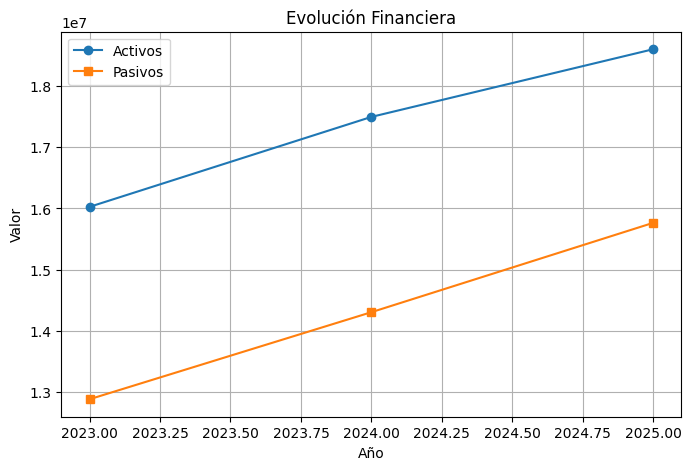

In [18]:
plt.figure(figsize=(8,5))
plt.plot(df['Año'], df['activos'], marker='o', label='Activos')
plt.plot(df['Año'], df['pasivos'], marker='s', label='Pasivos')

plt.title("Evolución Financiera")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree #prediccion para desempeño futuro

In [20]:
df_ml = df.copy()
# Crear variables para el modelo
df_ml['solvencia']     = (df_ml['patrimonio'] / df_ml['activos']) * 100
df_ml['endeudamiento'] = df_ml['pasivos'] / df_ml['patrimonio']
df_ml['margen']        = df_ml['utilidad'] / df_ml['ingresos']          #CALCULAMOS INDICADORES DE DF YA EXISTENTES

In [21]:
# Variable objetivo: 1 = bueno, 0 = malo
df_ml['desempeno'] = ((df_ml['solvencia'] > 15) & (df_ml['utilidad'] > 0)).astype(int)         #1= BUENO 0=MALO SI SOLVENCIA < 15% y utilidad POSITIVA

In [22]:
# Variables de entrada
FEATURES = ['solvencia', 'endeudamiento', 'margen']

# Crear y entrenar modelo

arbol = DecisionTreeClassifier(max_depth=2, random_state=42)
arbol.fit(df_ml[FEATURES], df_ml['desempeno'])                                   #ENTRENAR LOS DATOS CON LOS DATOS QUE LE DIMOS QUE SON LOS DE LOS 3 AÑOS ANTERIORES

DecisionTreeClassifier(max_depth=2, random_state=42)

In [23]:
# Datos proyectados para 2026
solvencia_2026     = 14.0    # %
endeudamiento_2026 = 5.5     # veces
margen_2026        = -0.02   # negativo = pérdida

# Crear DataFrame con los datos futuros
futuro = pd.DataFrame([{
    'solvencia': solvencia_2026,
    'endeudamiento': endeudamiento_2026,
    'margen': margen_2026
}])

In [24]:
resultado = arbol.predict(futuro)[0]
print(f"\n=== PREDICCIÓN 2026 ===")
print(f"  Solvencia proyectada  : {solvencia_2026}%")
print(f"  Endeudamiento         : {endeudamiento_2026}x")
print(f"  Margen de utilidad    : {margen_2026:.0%}")
print(f"  → Desempeño esperado  : {'BUENO ✓' if resultado == 1 else 'EN RIESGO ✗'}")


=== PREDICCIÓN 2026 ===
  Solvencia proyectada  : 14.0%
  Endeudamiento         : 5.5x
  Margen de utilidad    : -2%
  → Desempeño esperado  : EN RIESGO ✗


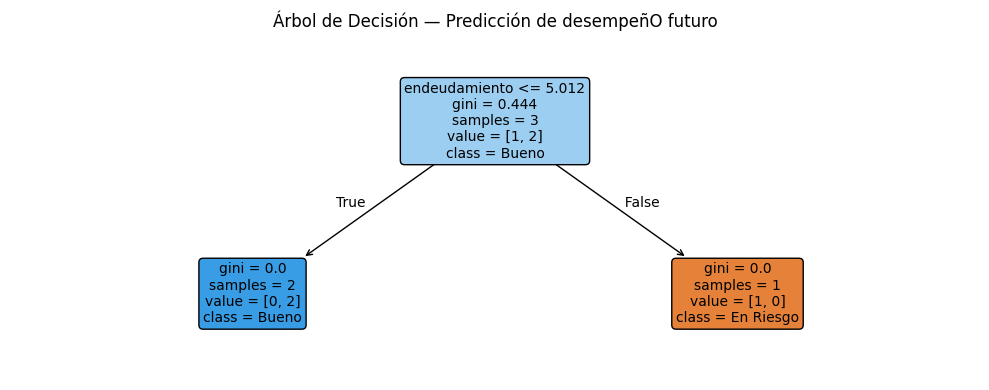

In [25]:
plt.figure(figsize=(10, 4))
plot_tree(arbol, feature_names=FEATURES, class_names=['En Riesgo', 'Bueno'],
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión — Predicción de desempeñO futuro")
plt.tight_layout()
plt.show()